In [116]:
import pandas as pd
bus_df = pd.read_csv("/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/raw/MTA_Bus_Hourly_Ridership__2020-2024_20250415.csv")
subway_df = pd.read_csv("/Users/ikmalbasirun/Documents/GitHub/NYC_Transportation_Demand/data/raw/MTA_Subway_Hourly_Ridership__2020-2024_20250415.csv")

In [117]:
subway_df.sample(5)

,transit_timestamp,transit_mode,station_complex_id,station_complex,borough,payment_method,fare_class_category,ridership,transfers,latitude,longitude,Georeference
84150,12/02/2024 05:00:00 AM,subway,243,"Church Av (F,G)",Brooklyn,metrocard,Metrocard - Fair Fare,7,0,40.644040,-73.979675,POINT (-73.979675 40.64404)
1629476,12/21/2024 08:00:00 AM,subway,217,"170 St (B,D)",Bronx,metrocard,Metrocard - Unlimited 30-Day,17,0,40.839306,-73.913400,POINT (-73.9134 40.839306)
874217,12/11/2024 10:00:00 PM,subway,90,"Van Siclen Av (J,Z)",Brooklyn,metrocard,Metrocard - Seniors & Disability,1,1,40.678024,-73.891685,POINT (-73.891685 40.678024)
73532,12/01/2024 11:00:00 PM,subway,311,86 St (1),Manhattan,metrocard,Metrocard - Unlimited 30-Day,15,0,40.788643,-73.976220,POINT (-73.97622 40.788643)
1729290,12/22/2024 03:00:00 PM,subway,198,Howard Beach-JFK Airport (A),Queens,metrocard,Metrocard - Unlimited 30-Day,1,0,40.660477,-73.830300,POINT (-73.8303 40.660477)


In [118]:
bus_df.sample(5)

,transit_timestamp,bus_route,ridership,payment_method,fare_class_category,transfers
5673996,12/25/2024 07:00:00 AM,SIM1C,0,metrocard,OMNY - Seniors & Disability,0
3686629,12/16/2024 07:00:00 PM,BX26,1,metrocard,Metrocard - Seniors & Disability,0
4218832,12/19/2024 02:00:00 AM,Q77,0,metrocard,OMNY - Students,0
5496094,12/24/2024 01:00:00 PM,Q35,0,omny,Metrocard - Seniors & Disability,0
1152885,12/05/2024 10:00:00 PM,Q60,0,omny,Metrocard - Full Fare,0


Transformation

In [ ]:
bus_df['transit_timestamp'] = pd.to_datetime(bus_df['transit_timestamp'])

bus_df['date'] = pd.to_datetime(bus_df['transit_timestamp'].dt.date)
bus_df['hour'] = bus_df['transit_timestamp'].dt.hour

bus_df.drop(columns=['fare_class_category', 'transfers', 'payment_method','transit_timestamp'], inplace=True)

bus_df = bus_df.groupby(['date', 'hour' 'bus_route']).sum('ridership').reset_index()

bus_df.rename(
    columns={'ridership':'demand'},
    inplace=True
    )

/var/folders/0b/920j3nln4yn8tz94rztlp5900000gn/T/ipykernel_9376/3746140141.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  bus_df['datetime'] = pd.to_datetime(bus_df['transit_timestamp'])


In [120]:
bus_df.sample(10)

,datetime,bus_route,demand
39034,2024-12-05 00:00:00,M116,14
299154,2024-12-31 18:00:00,Q65,713
275640,2024-12-29 08:00:00,Q37,94
24271,2024-12-03 11:00:00,X10B,0
229006,2024-12-24 13:00:00,M7,513
190030,2024-12-20 13:00:00,BX18A,17
292753,2024-12-31 02:00:00,SIM1,0
292201,2024-12-31 01:00:00,Q10,93
64535,2024-12-07 15:00:00,J90,0
119405,2024-12-13 06:00:00,S89,22


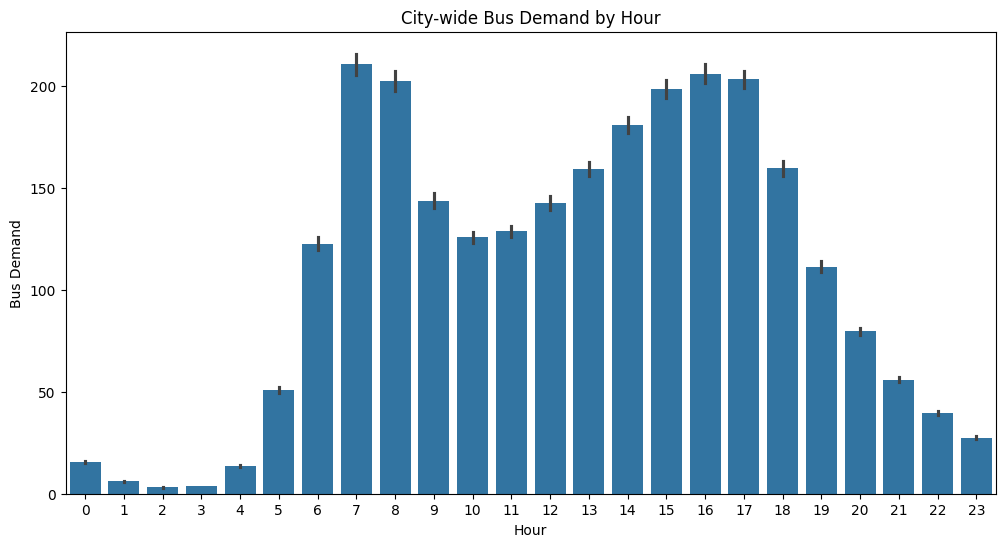

In [123]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(data=bus_df, x=bus_df['datetime'].dt.hour, y='demand')

plt.xlabel("Hour")
plt.ylabel("Bus Demand")
plt.title("City-wide Bus Demand by Hour")
plt.show()

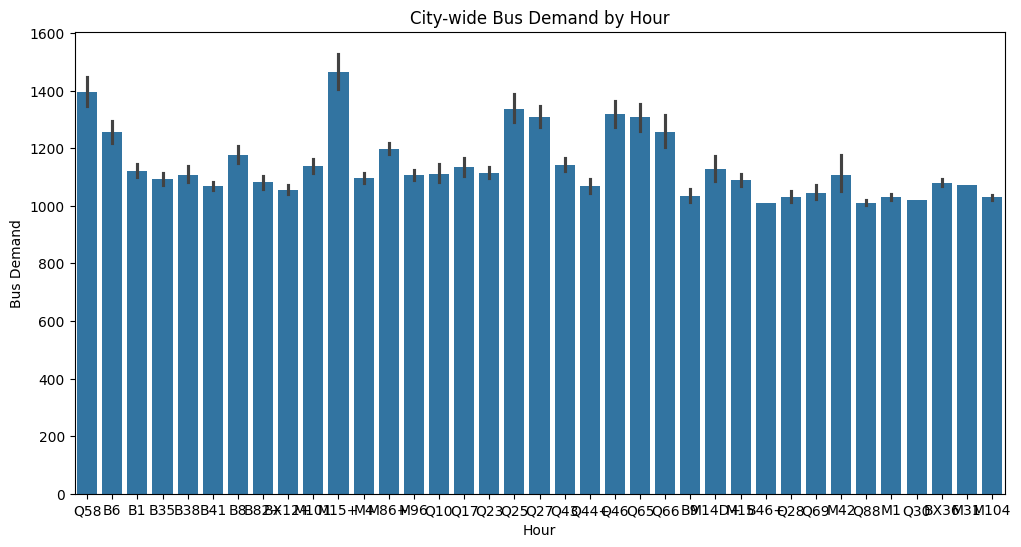

In [132]:
import seaborn as sns
import matplotlib.pyplot as plt

filtered_df = bus_df.loc[bus_df['demand'] > 1000, ['bus_route', 'demand']]

plt.figure(figsize=(12,6))
sns.barplot(data=filtered_df, x='bus_route', y='demand')

plt.xlabel("Hour")
plt.ylabel("Bus Demand")
plt.title("City-wide Bus Demand by Hour")
plt.show()